In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

In [2]:
sns.set_theme(style='whitegrid', font_scale=1.15)
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'axes.titlesize': 15,
    'axes.labelsize': 12,
    'font.family': 'sans-serif',
    'figure.dpi': 120,
    'savefig.bbox': 'tight'
})

PALETTE = sns.color_palette('Set2')
CLASS_PAL = {'Low': '#e74c3c', 'Medium': '#f39c12', 'High': '#27ae60'}

In [3]:
# read dataset
data_path = '/content/drive/MyDrive/JCAIEAH-003/Notes and Hands On/day-12/Smartphone_Usage_Productivity_Dataset_50000.csv'
df = pd.read_csv(data_path)
df.shape

(50000, 13)

In [4]:
df.head()

,User_ID,Age,Gender,Occupation,Device_Type,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours
0,U1,58,Male,Professional,Android,1.3,6.7,6,8.8,4,42,1,8.7
1,U2,25,Male,Professional,Android,1.2,1.5,5,6.4,1,51,3,5.1
2,U3,19,Male,Student,iOS,5.3,5.7,5,9.0,4,14,5,6.3
3,U4,35,Female,Business Owner,iOS,5.8,2.5,2,5.7,3,36,6,12.8
4,U5,33,Male,Freelancer,Android,7.9,1.3,4,5.7,3,37,5,9.9


In [5]:
# show dataframe information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   User_ID                    50000 non-null  object 
 1   Age                        50000 non-null  int64  
 2   Gender                     50000 non-null  object 
 3   Occupation                 50000 non-null  object 
 4   Device_Type                50000 non-null  object 
 5   Daily_Phone_Hours          50000 non-null  float64
 6   Social_Media_Hours         50000 non-null  float64
 7   Work_Productivity_Score    50000 non-null  int64  
 8   Sleep_Hours                50000 non-null  float64
 9   Stress_Level               50000 non-null  int64  
 10  App_Usage_Count            50000 non-null  int64  
 11  Caffeine_Intake_Cups       50000 non-null  int64  
 12  Weekend_Screen_Time_Hours  50000 non-null  float64
dtypes: float64(4), int64(5), object(4)
memory usag

In [7]:
# check missing value
df.isnull().sum()

,0
User_ID,0
Age,0
Gender,0
Occupation,0
Device_Type,0
Daily_Phone_Hours,0
Social_Media_Hours,0
Work_Productivity_Score,0
Sleep_Hours,0
Stress_Level,0


In [8]:
# show descriptive statistic
df.describe()

,Age,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000
mean,39.034960,6.509116,4.267250,5.503760,6.497744,5.504500,32.43898,3.004580,8.006844
std,12.414877,3.170903,2.164743,2.874806,1.449551,2.871095,16.12151,1.996657,3.461300
min,18.000000,1.000000,0.500000,1.000000,4.000000,1.000000,5.00000,0.000000,2.000000
25%,28.000000,3.800000,2.400000,3.000000,5.200000,3.000000,18.00000,1.000000,5.000000
50%,39.000000,6.500000,4.300000,5.500000,6.500000,6.000000,32.00000,3.000000,8.000000
75%,50.000000,9.200000,6.100000,8.000000,7.800000,8.000000,46.00000,5.000000,11.000000
max,60.000000,12.000000,8.000000,10.000000,9.000000,10.000000,60.00000,6.000000,14.000000


In [9]:
# show descriptive statistic with non-numeric data
df.describe(include='object')

,User_ID,Gender,Occupation,Device_Type
count,50000,50000,50000,50000
unique,50000,3,4,2
top,U49984,Male,Professional,Android
freq,1,16708,12629,25080


In [10]:
# Data Cleaning & Feature Engineering

# Drop non-analytic identifier
df.drop(columns=['User_ID'], inplace=True)

# Flag anomalous rows
df['Data_Anomaly'] = (df['Social_Media_Hours'] > df['Daily_Phone_Hours']).astype(int)

# ── Feature Engineering ──
df['Phone_Addiction_Ratio'] = (df['Daily_Phone_Hours'] / 24).round(4)
df['Weekend_vs_Weekday_Ratio'] = (df['Weekend_Screen_Time_Hours'] / df['Daily_Phone_Hours']).round(4)
df['Social_Media_Pct'] = (df['Social_Media_Hours'] / df['Daily_Phone_Hours']).clip(upper=1.0).round(4)

# ── Bin Targets into Classes ──
def bin_score(score):
    if score <= 3:
        return 'Low'
    elif score <= 7:
        return 'Medium'
    else:
        return 'High'

df['Productivity_Class'] = df['Work_Productivity_Score'].apply(bin_score)
df['Stress_Class'] = df['Stress_Level'].apply(bin_score)

# Make classes ordered categoricals for proper plotting
class_order = ['Low', 'Medium', 'High']
df['Productivity_Class'] = pd.Categorical(df['Productivity_Class'], categories=class_order, ordered=True)
df['Stress_Class'] = pd.Categorical(df['Stress_Class'], categories=class_order, ordered=True)

print(f'✅ Feature engineering complete. New shape: {df.shape}')
print(f'\nNew columns: Phone_Addiction_Ratio, Weekend_vs_Weekday_Ratio, Social_Media_Pct,')
print(f'             Productivity_Class, Stress_Class, Data_Anomaly')
print(f'\nProductivity Class Distribution:')
print(df['Productivity_Class'].value_counts().sort_index())
print(f'\nStress Class Distribution:')
print(df['Stress_Class'].value_counts().sort_index())

✅ Feature engineering complete. New shape: (50000, 18)

New columns: Phone_Addiction_Ratio, Weekend_vs_Weekday_Ratio, Social_Media_Pct,
             Productivity_Class, Stress_Class, Data_Anomaly

Productivity Class Distribution:
Productivity_Class
Low       14960
Medium    20052
High      14988
Name: count, dtype: int64

Stress Class Distribution:
Stress_Class
Low       15007
Medium    19976
High      15017
Name: count, dtype: int64


In [11]:
df.head()

,Age,Gender,Occupation,Device_Type,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours,Data_Anomaly,Phone_Addiction_Ratio,Weekend_vs_Weekday_Ratio,Social_Media_Pct,Productivity_Class,Stress_Class
0,58,Male,Professional,Android,1.3,6.7,6,8.8,4,42,1,8.7,1,0.0542,6.6923,1.0000,Medium,Medium
1,25,Male,Professional,Android,1.2,1.5,5,6.4,1,51,3,5.1,1,0.0500,4.2500,1.0000,Medium,Low
2,19,Male,Student,iOS,5.3,5.7,5,9.0,4,14,5,6.3,1,0.2208,1.1887,1.0000,Medium,Medium
3,35,Female,Business Owner,iOS,5.8,2.5,2,5.7,3,36,6,12.8,0,0.2417,2.2069,0.4310,Low,Low
4,33,Male,Freelancer,Android,7.9,1.3,4,5.7,3,37,5,9.9,0,0.3292,1.2532,0.1646,Medium,Low


/tmp/ipython-input-1308537750.py:24: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


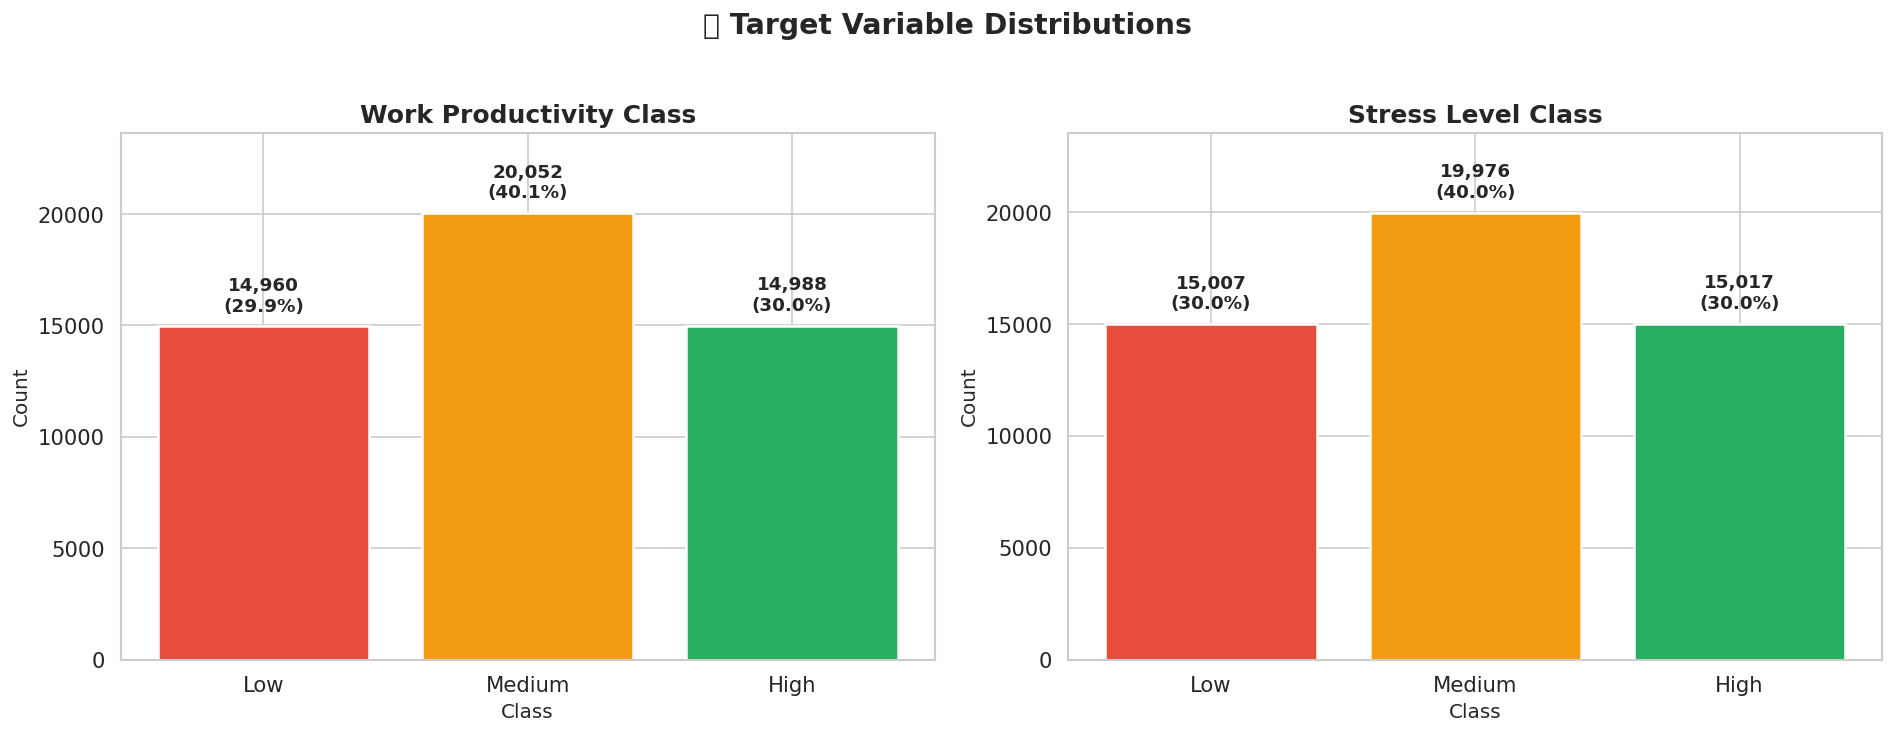

In [12]:
# Target Class Distributions

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, col, title in zip(axes, ['Productivity_Class', 'Stress_Class'],
                           ['Work Productivity Class', 'Stress Level Class']):
    order = ['Low', 'Medium', 'High']
    counts = df[col].value_counts().reindex(order)
    total = counts.sum()

    bars = ax.bar(order, counts, color=[CLASS_PAL[c] for c in order], edgecolor='white', linewidth=1.5)

    for bar, count in zip(bars, counts):
        pct = count / total * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total*0.01,
                f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontweight='bold', fontsize=11)

    ax.set_title(title, fontsize=15, fontweight='bold')
    ax.set_xlabel('Class')
    ax.set_ylabel('Count')
    ax.set_ylim(0, counts.max() * 1.18)

plt.suptitle('📊 Target Variable Distributions', fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

/tmp/ipython-input-3401632661.py:20: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


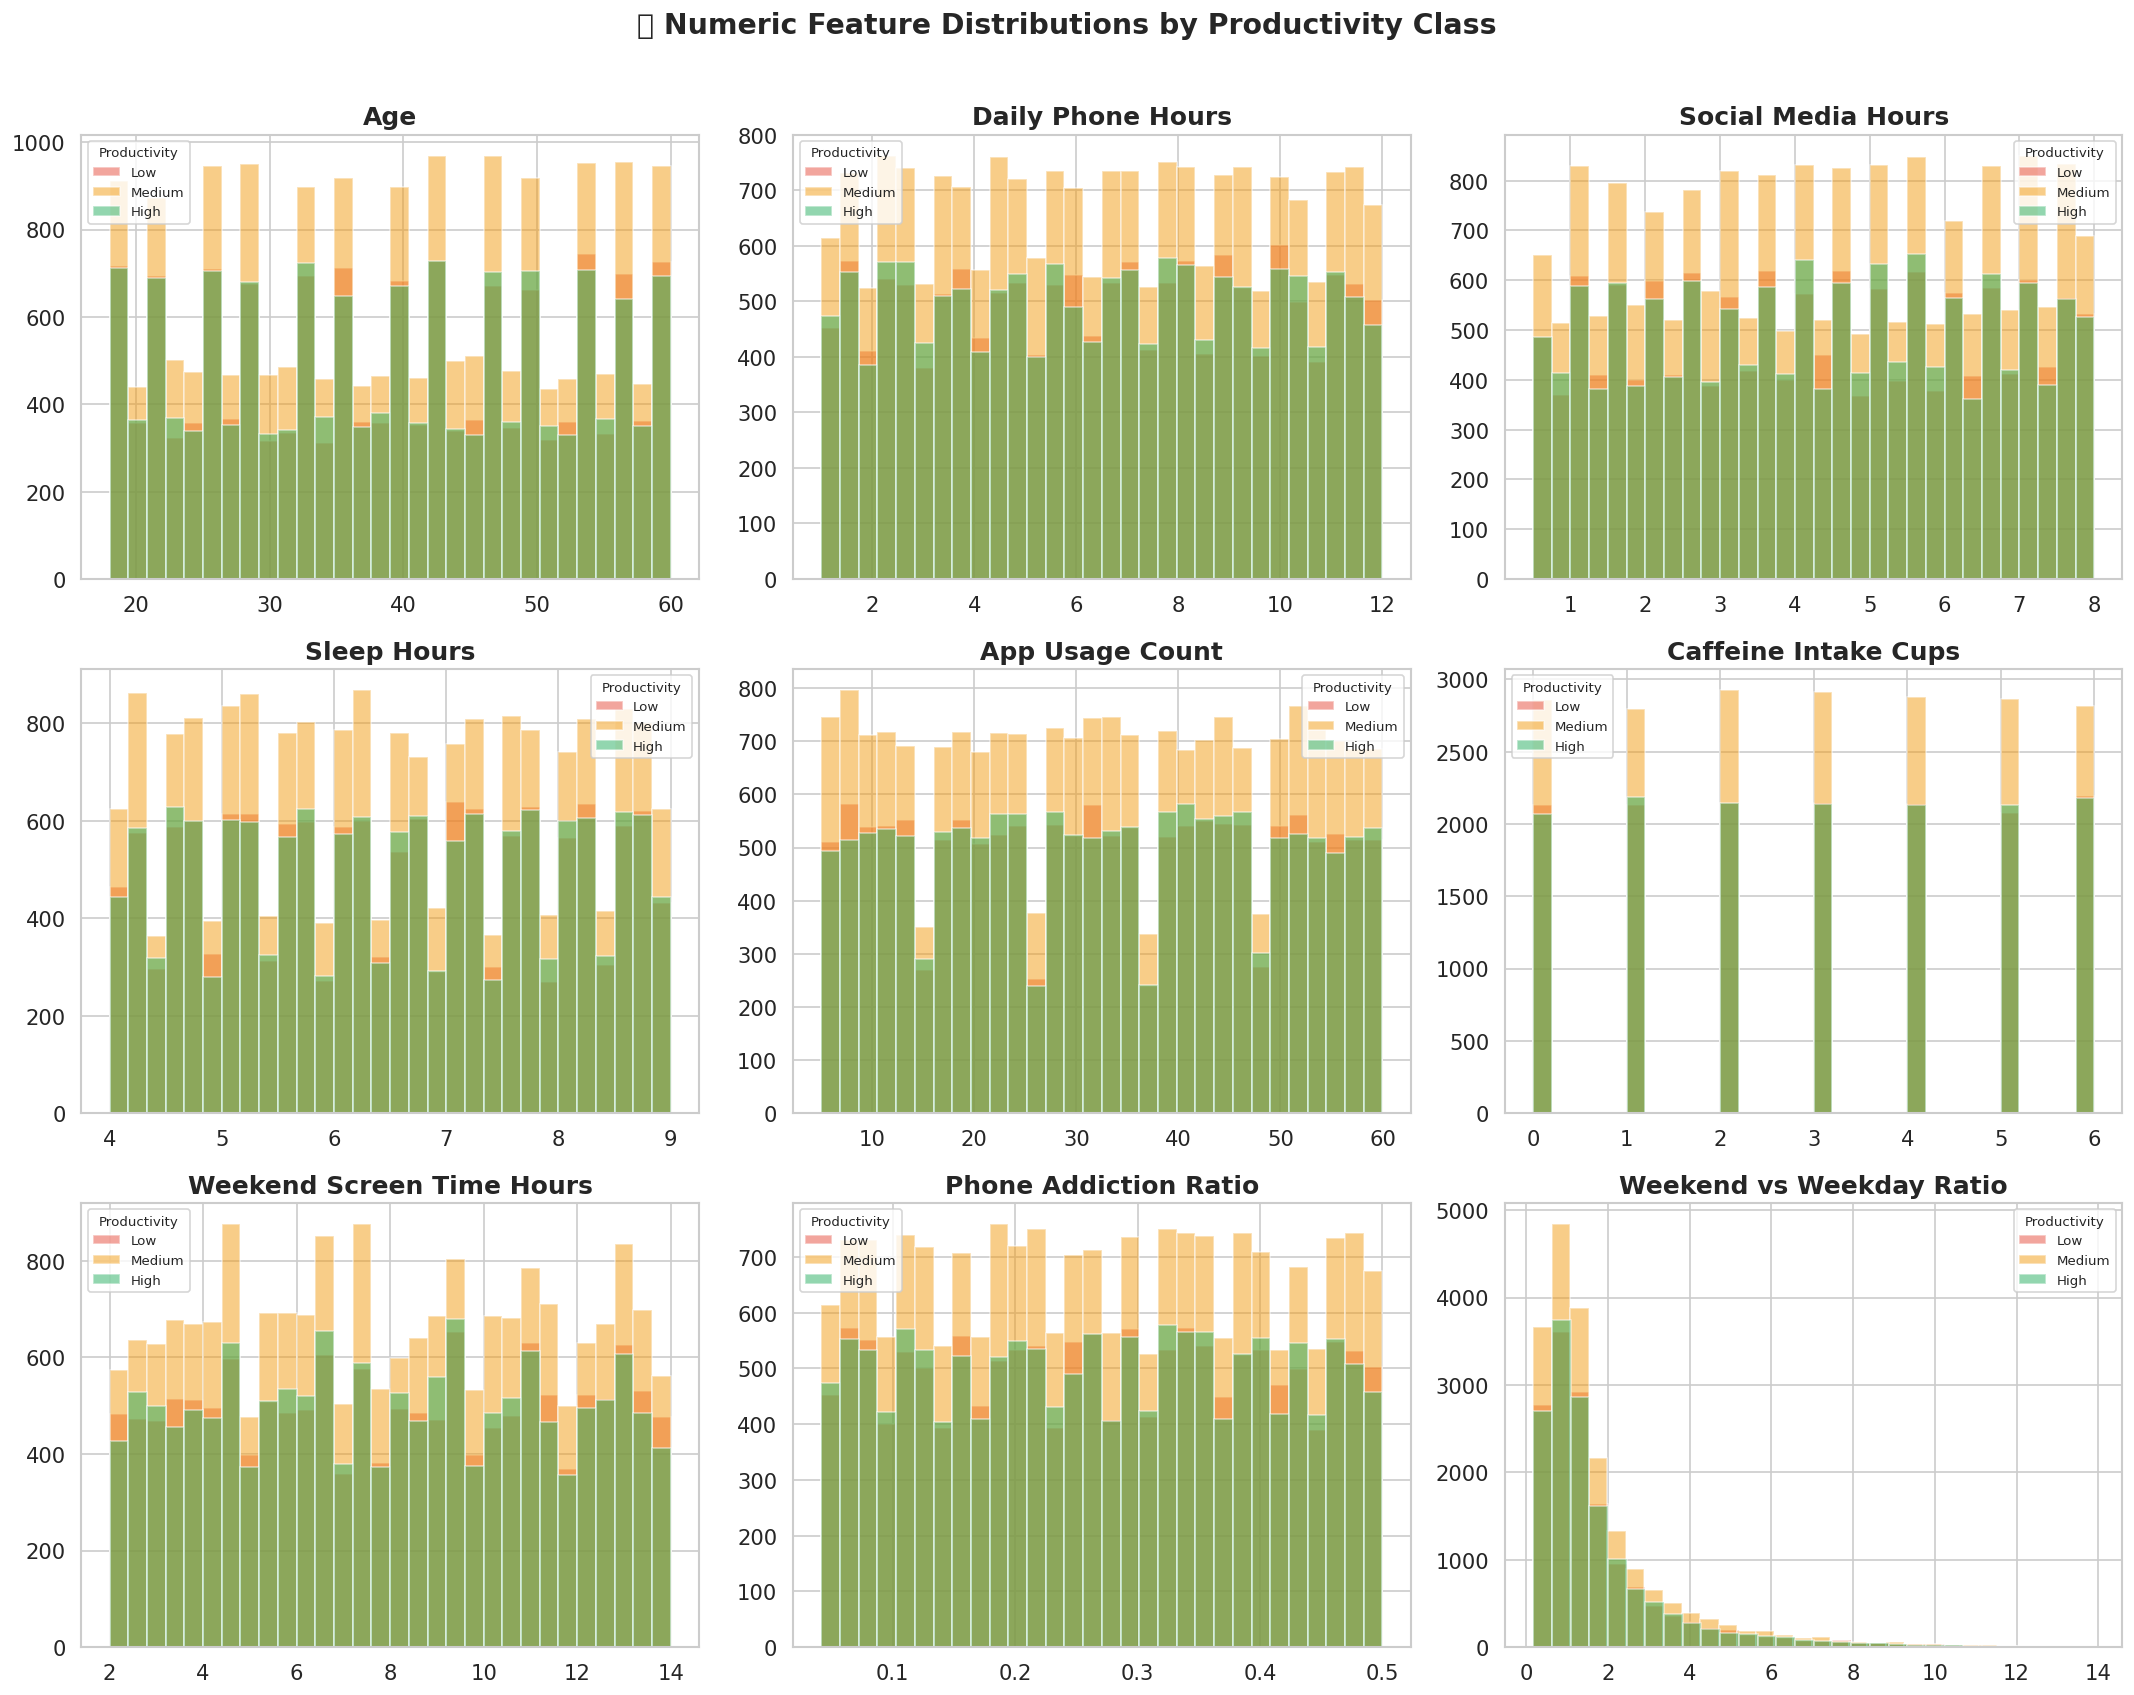

In [13]:
# Numeric Feature Distributions

num_cols = ['Age', 'Daily_Phone_Hours', 'Social_Media_Hours', 'Sleep_Hours',
            'App_Usage_Count', 'Caffeine_Intake_Cups', 'Weekend_Screen_Time_Hours',
            'Phone_Addiction_Ratio', 'Weekend_vs_Weekday_Ratio']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.ravel()

for i, col in enumerate(num_cols):
    ax = axes[i]
    for cls in ['Low', 'Medium', 'High']:
        subset = df[df['Productivity_Class'] == cls][col]
        ax.hist(subset, bins=30, alpha=0.5, label=cls, color=CLASS_PAL[cls], edgecolor='white')
    ax.set_title(col.replace('_', ' '), fontweight='bold')
    ax.set_xlabel('')
    ax.legend(fontsize=8, title='Productivity', title_fontsize=8)

plt.suptitle('📈 Numeric Feature Distributions by Productivity Class', fontsize=17, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

/tmp/ipython-input-3621922462.py:32: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


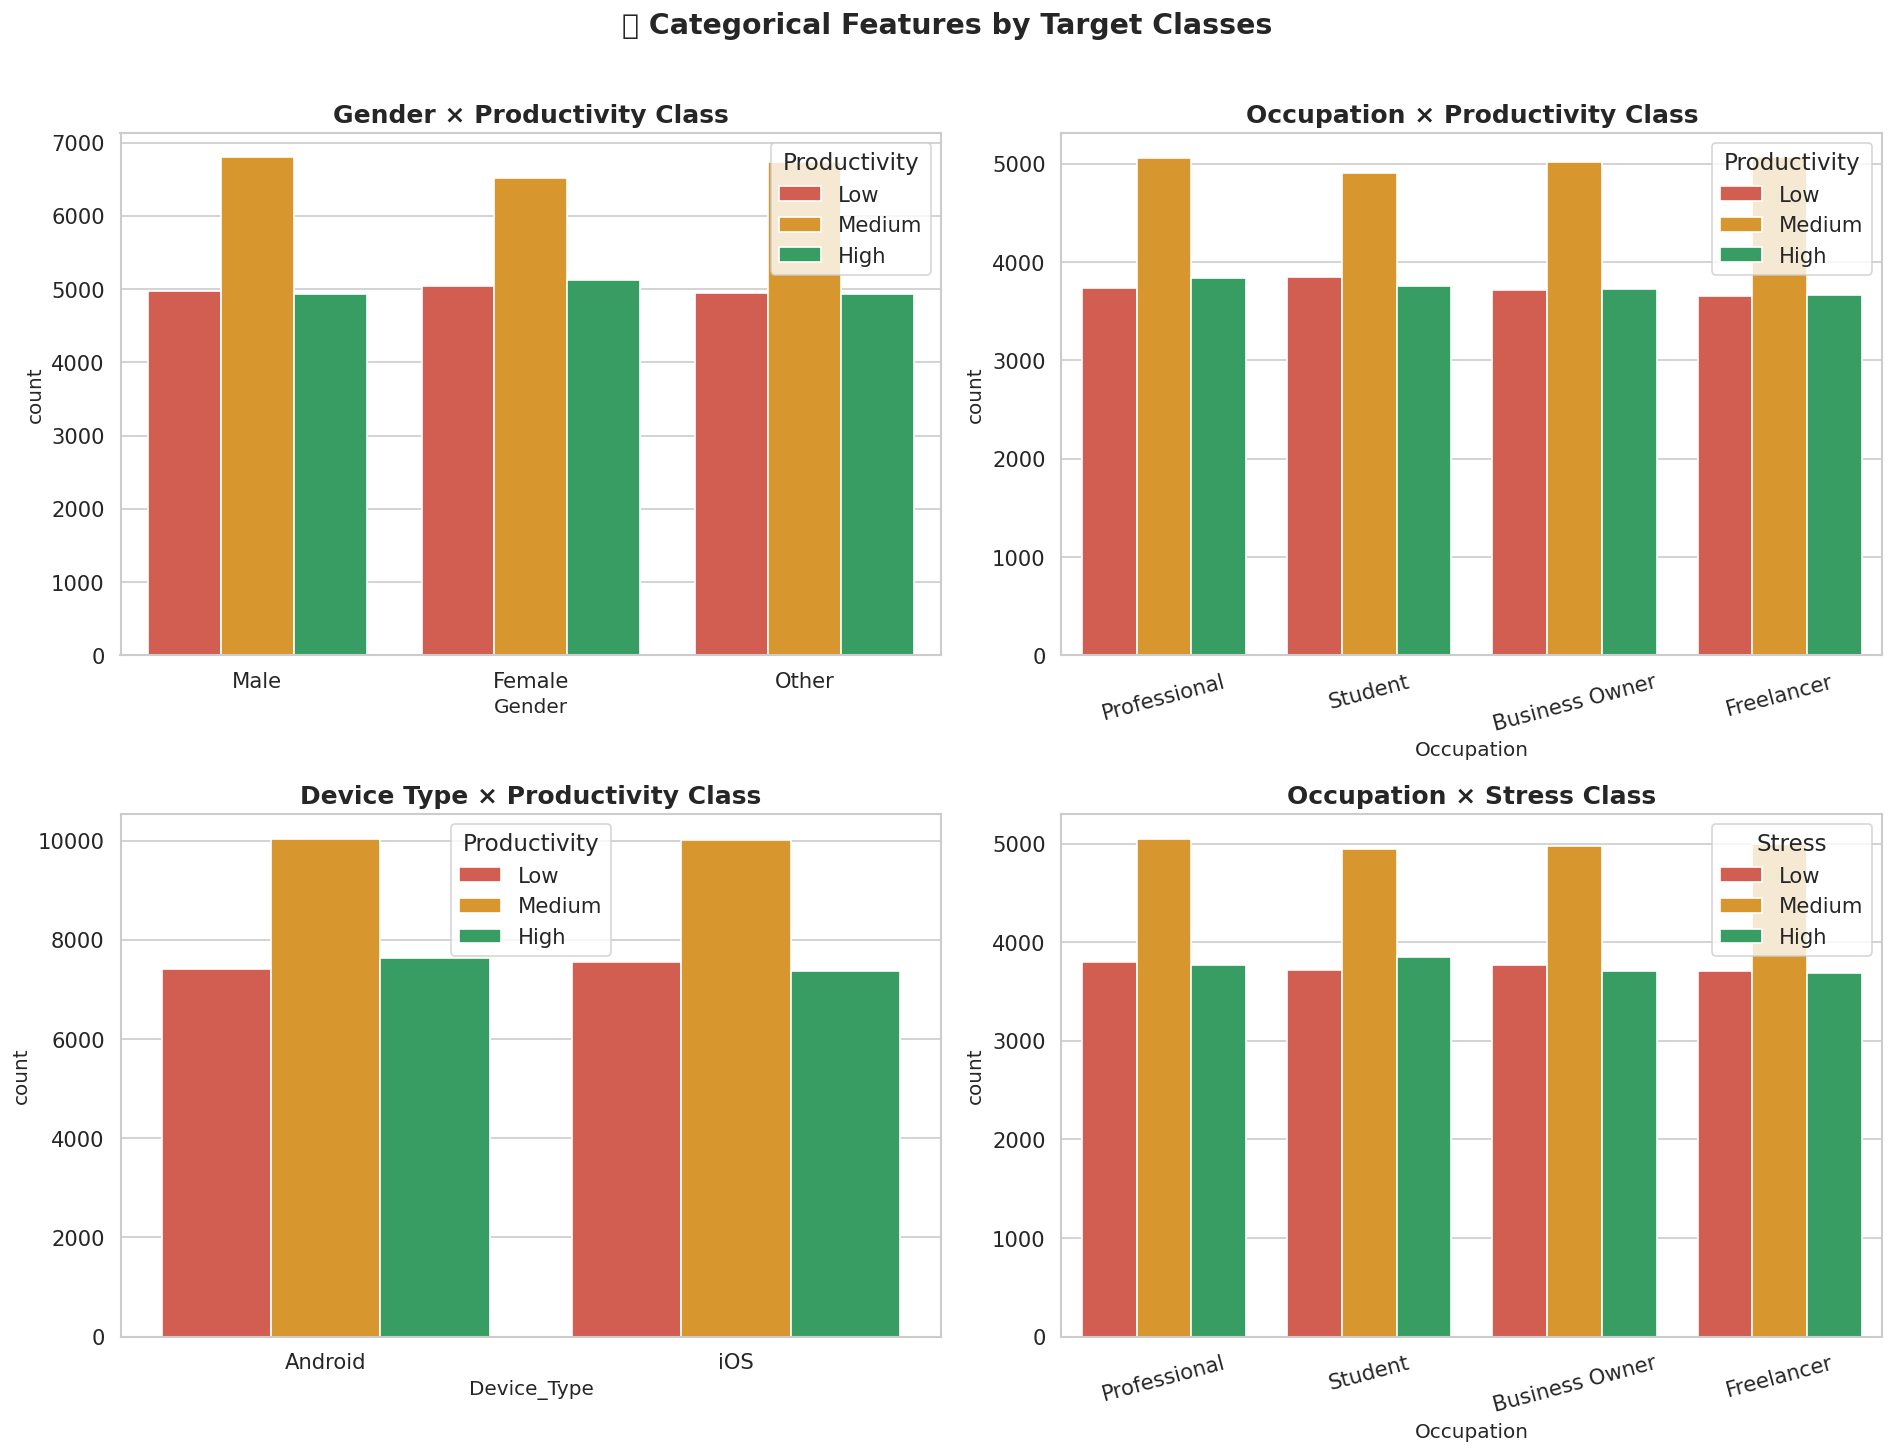

In [14]:
# Categorical Feature Breakdowns

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Gender × Productivity
sns.countplot(data=df, x='Gender', hue='Productivity_Class', ax=axes[0, 0],
              palette=CLASS_PAL, hue_order=['Low', 'Medium', 'High'], edgecolor='white')
axes[0, 0].set_title('Gender × Productivity Class', fontweight='bold')
axes[0, 0].legend(title='Productivity')

# Occupation × Productivity
sns.countplot(data=df, x='Occupation', hue='Productivity_Class', ax=axes[0, 1],
              palette=CLASS_PAL, hue_order=['Low', 'Medium', 'High'], edgecolor='white')
axes[0, 1].set_title('Occupation × Productivity Class', fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=15)
axes[0, 1].legend(title='Productivity')

# Device Type × Productivity
sns.countplot(data=df, x='Device_Type', hue='Productivity_Class', ax=axes[1, 0],
              palette=CLASS_PAL, hue_order=['Low', 'Medium', 'High'], edgecolor='white')
axes[1, 0].set_title('Device Type × Productivity Class', fontweight='bold')
axes[1, 0].legend(title='Productivity')

# Occupation × Stress
sns.countplot(data=df, x='Occupation', hue='Stress_Class', ax=axes[1, 1],
              palette=CLASS_PAL, hue_order=['Low', 'Medium', 'High'], edgecolor='white')
axes[1, 1].set_title('Occupation × Stress Class', fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=15)
axes[1, 1].legend(title='Stress')

plt.suptitle('📊 Categorical Features by Target Classes', fontsize=17, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

/tmp/ipython-input-2443217660.py:20: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


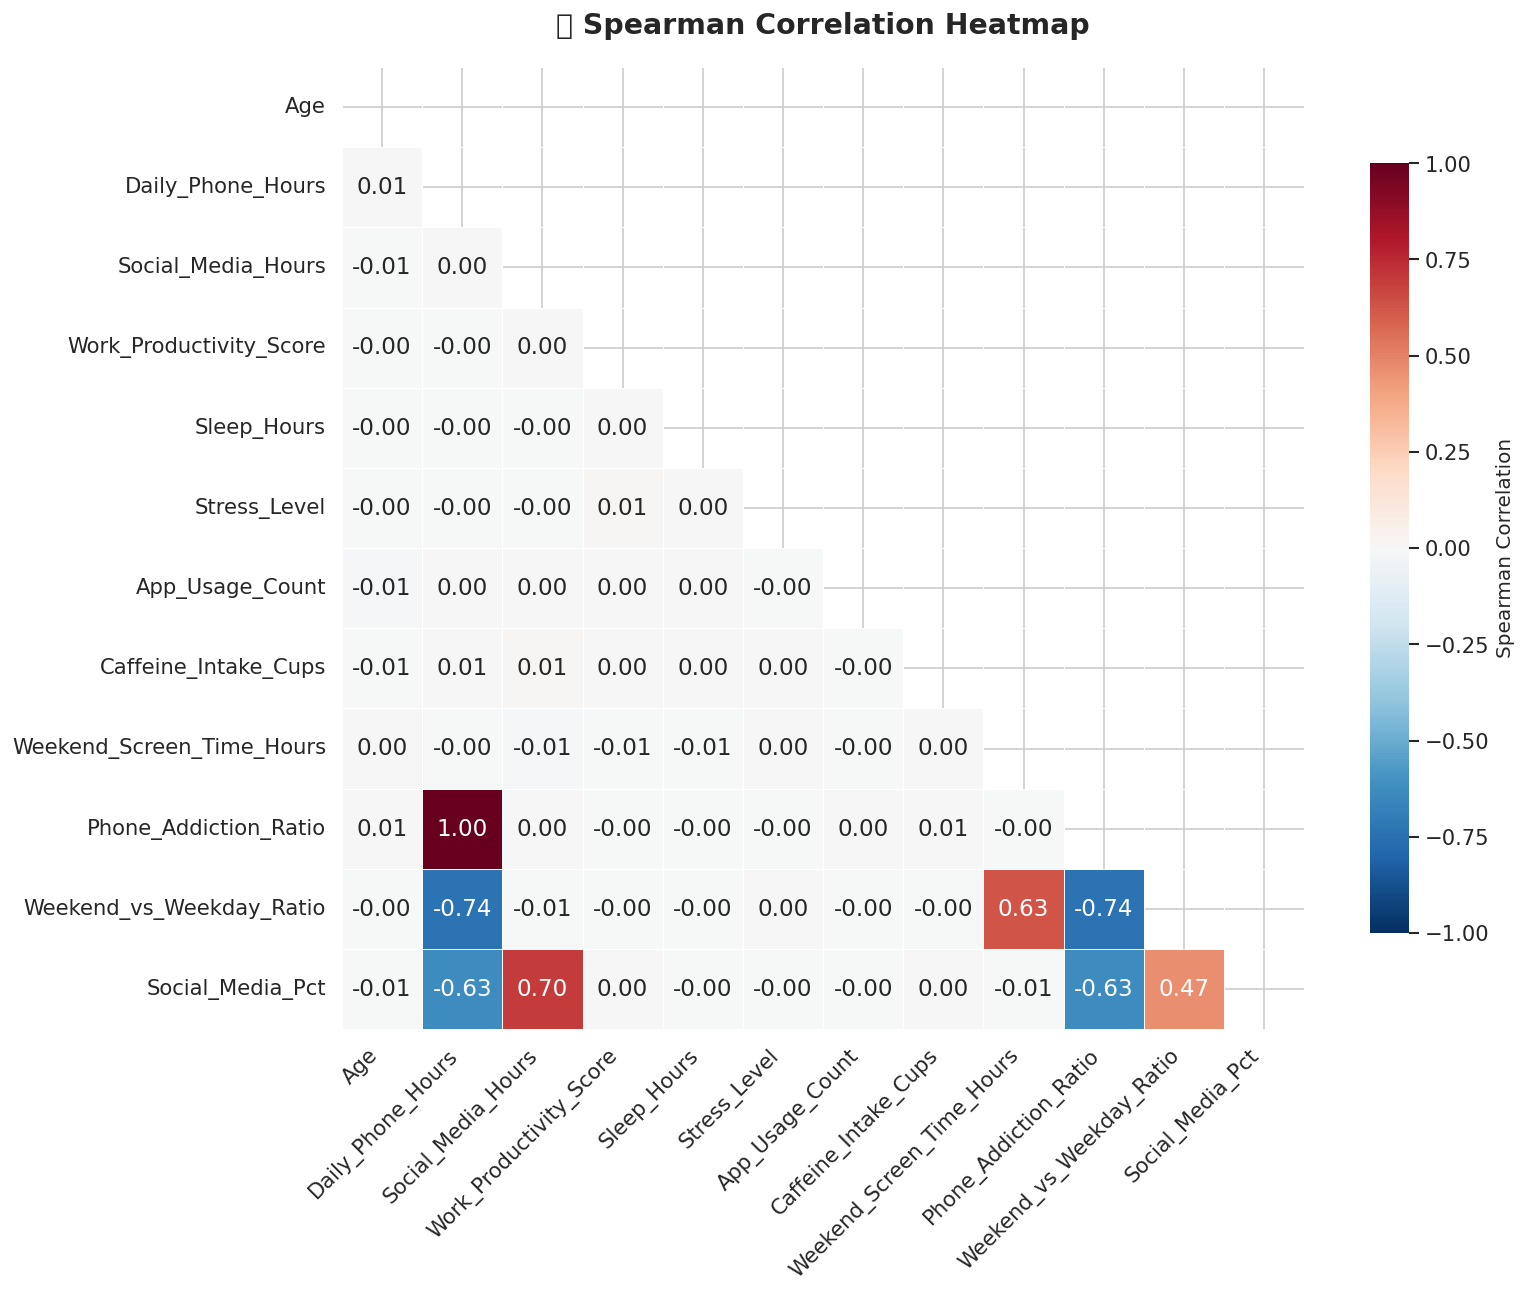

Top correlations with Work_Productivity_Score:
Stress_Level                 0.009769
Weekend_Screen_Time_Hours    0.005314
Social_Media_Hours           0.003651
Age                          0.003481
Sleep_Hours                  0.003238

Top correlations with Stress_Level:
Work_Productivity_Score     0.009769
Weekend_vs_Weekday_Ratio    0.004938
Sleep_Hours                 0.004666
Daily_Phone_Hours           0.002753
Phone_Addiction_Ratio       0.002753


In [15]:
# Correlation Analysis (Spearman)

corr_cols = ['Age', 'Daily_Phone_Hours', 'Social_Media_Hours', 'Work_Productivity_Score',
             'Sleep_Hours', 'Stress_Level', 'App_Usage_Count', 'Caffeine_Intake_Cups',
             'Weekend_Screen_Time_Hours', 'Phone_Addiction_Ratio', 'Weekend_vs_Weekday_Ratio',
             'Social_Media_Pct']

corr_matrix = df[corr_cols].corr(method='spearman')

# Mask upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'label': 'Spearman Correlation', 'shrink': 0.8}, ax=ax)

ax.set_title('🔗 Spearman Correlation Heatmap', fontsize=17, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Top correlations with targets
print('Top correlations with Work_Productivity_Score:')
prod_corr = corr_matrix['Work_Productivity_Score'].drop('Work_Productivity_Score').abs().sort_values(ascending=False)
print(prod_corr.head(5).to_string())
print(f'\nTop correlations with Stress_Level:')
stress_corr = corr_matrix['Stress_Level'].drop('Stress_Level').abs().sort_values(ascending=False)
print(stress_corr.head(5).to_string())

/tmp/ipython-input-1026588165.py:39: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


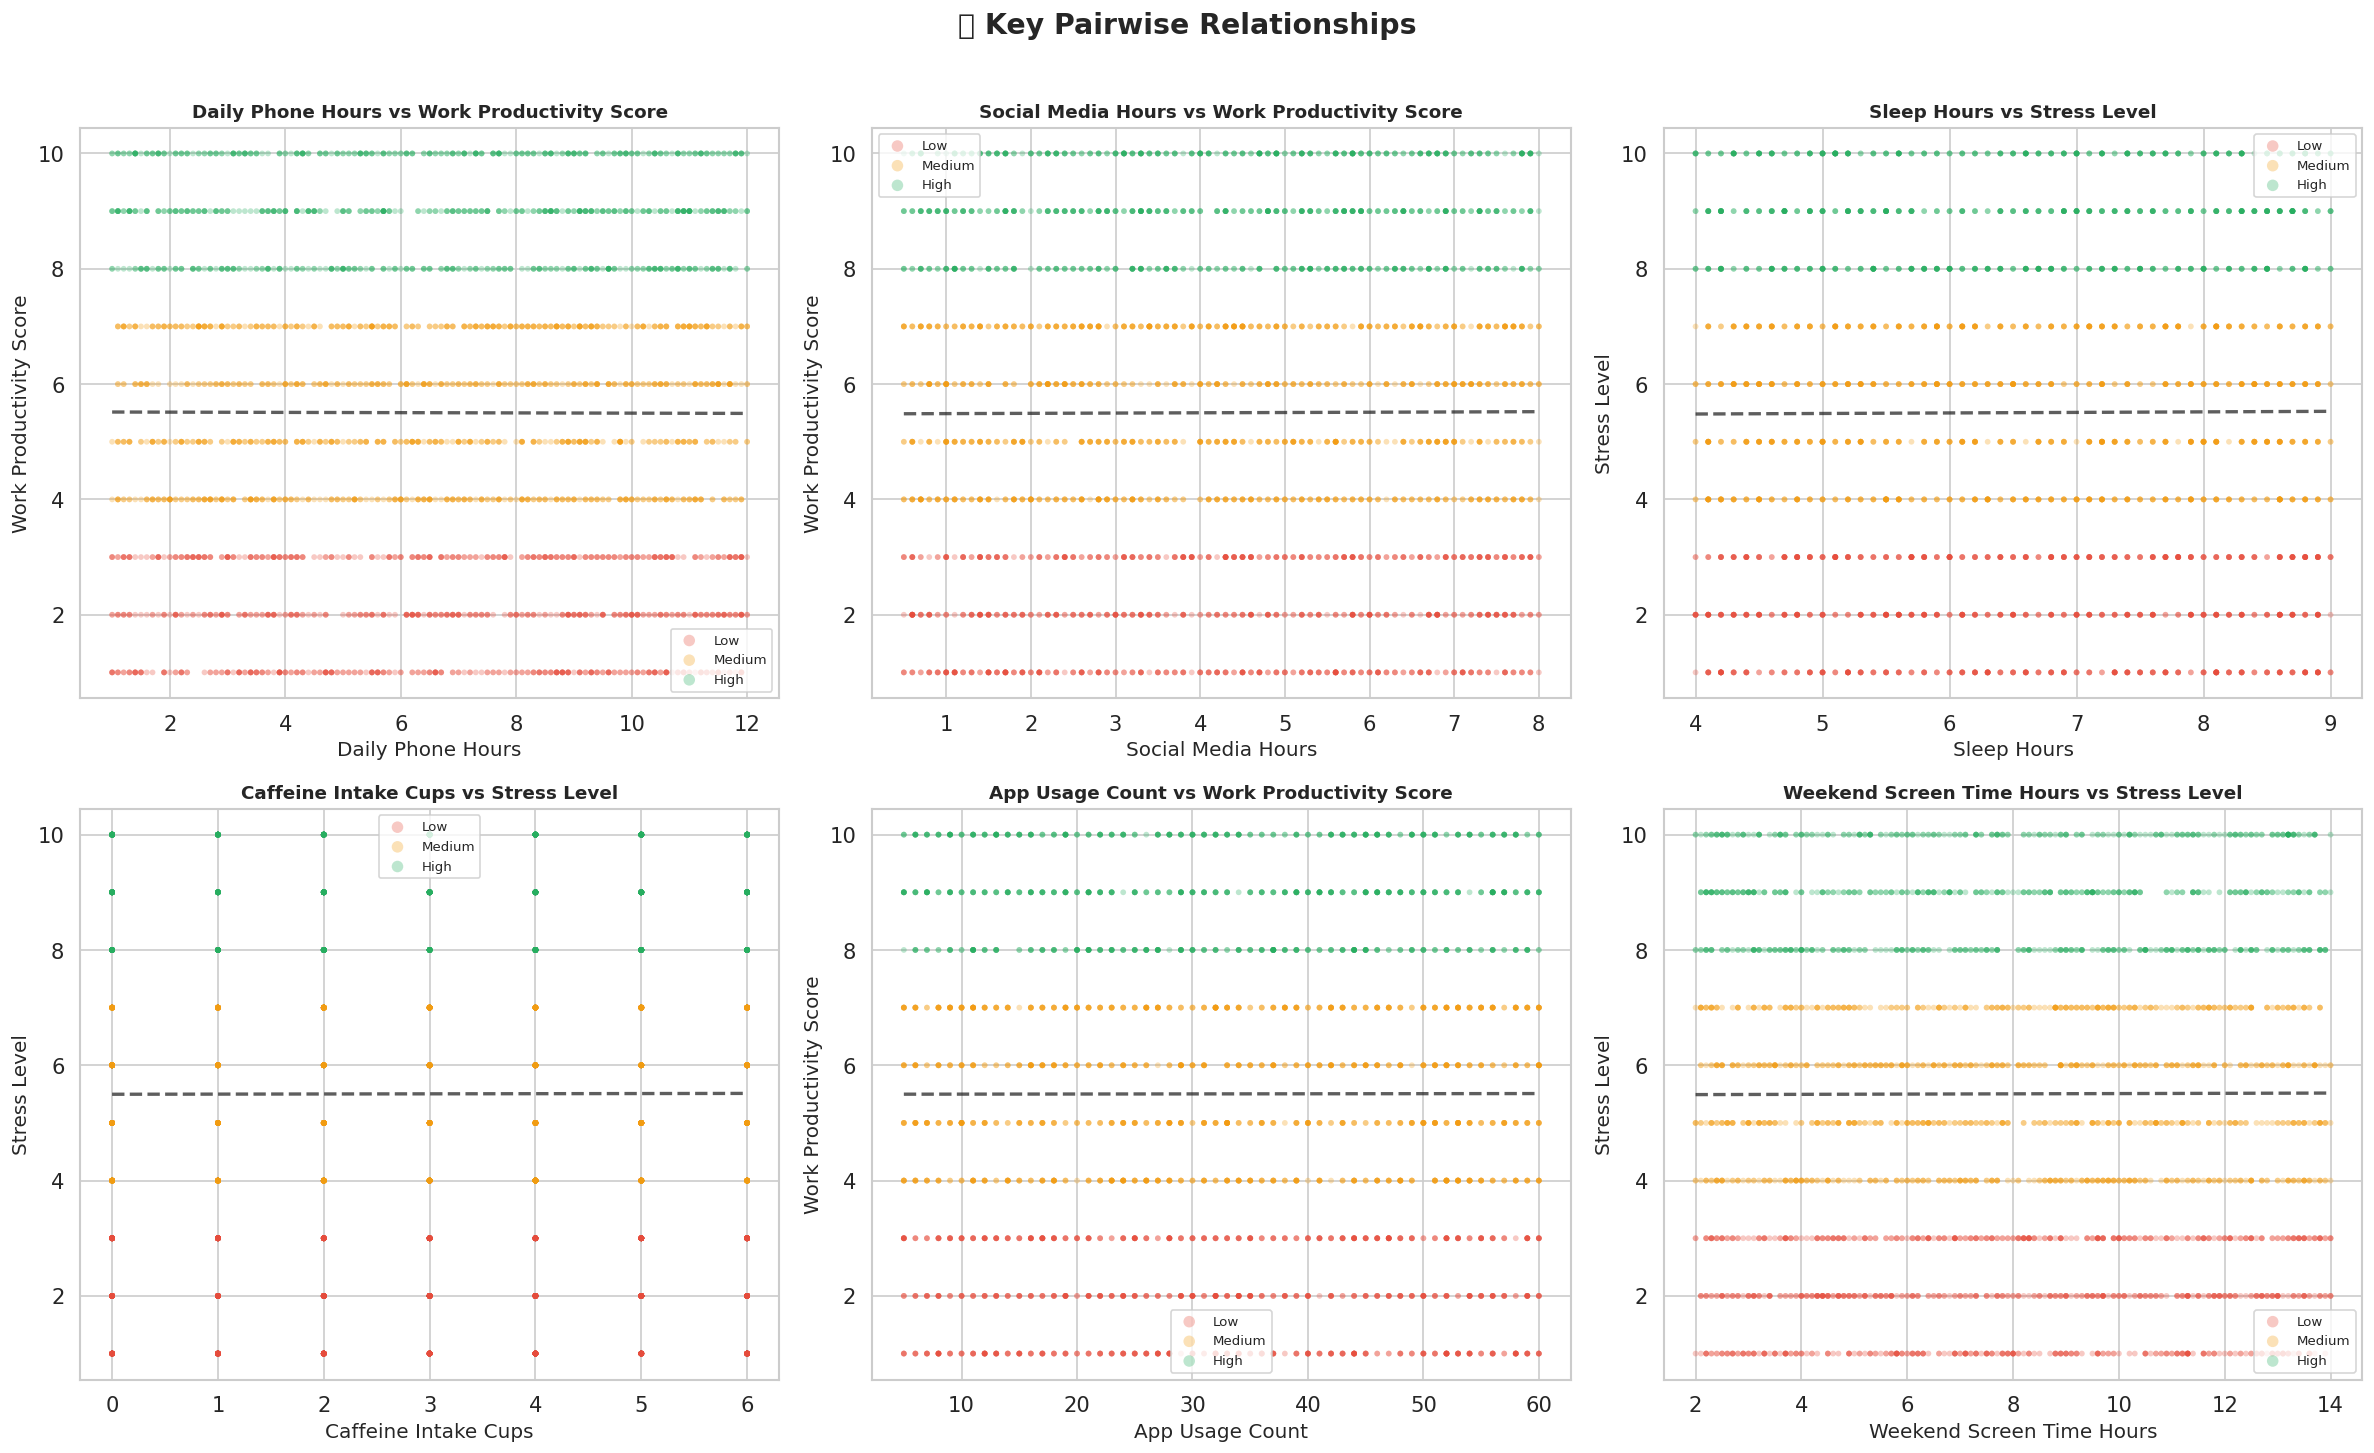

In [16]:
# Pairwise Relationships — Key Feature Pairs

pairs = [
    ('Daily_Phone_Hours', 'Work_Productivity_Score'),
    ('Social_Media_Hours', 'Work_Productivity_Score'),
    ('Sleep_Hours', 'Stress_Level'),
    ('Caffeine_Intake_Cups', 'Stress_Level'),
    ('App_Usage_Count', 'Work_Productivity_Score'),
    ('Weekend_Screen_Time_Hours', 'Stress_Level'),
]

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.ravel()

for i, (x_col, y_col) in enumerate(pairs):
    ax = axes[i]
    hue_col = 'Productivity_Class' if 'Productivity' in y_col else 'Stress_Class'

    # Sample for scatter to avoid overplotting
    sample = df.sample(n=min(3000, len(df)), random_state=42)

    for cls in ['Low', 'Medium', 'High']:
        sub = sample[sample[hue_col] == cls]
        ax.scatter(sub[x_col], sub[y_col], alpha=0.3, s=12,
                   color=CLASS_PAL[cls], label=cls, edgecolors='none')

    # Add regression line
    z = np.polyfit(df[x_col], df[y_col], 1)
    p = np.poly1d(z)
    x_range = np.linspace(df[x_col].min(), df[x_col].max(), 100)
    ax.plot(x_range, p(x_range), 'k--', linewidth=2, alpha=0.7)

    ax.set_xlabel(x_col.replace('_', ' '))
    ax.set_ylabel(y_col.replace('_', ' '))
    ax.set_title(f'{x_col.replace("_", " ")} vs {y_col.replace("_", " ")}', fontweight='bold', fontsize=11)
    ax.legend(fontsize=8, markerscale=2)

plt.suptitle('🔍 Key Pairwise Relationships', fontsize=17, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

/tmp/ipython-input-2594827696.py:18: UserWarning: Glyph 128101 (\N{BUSTS IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128101 (\N{BUSTS IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


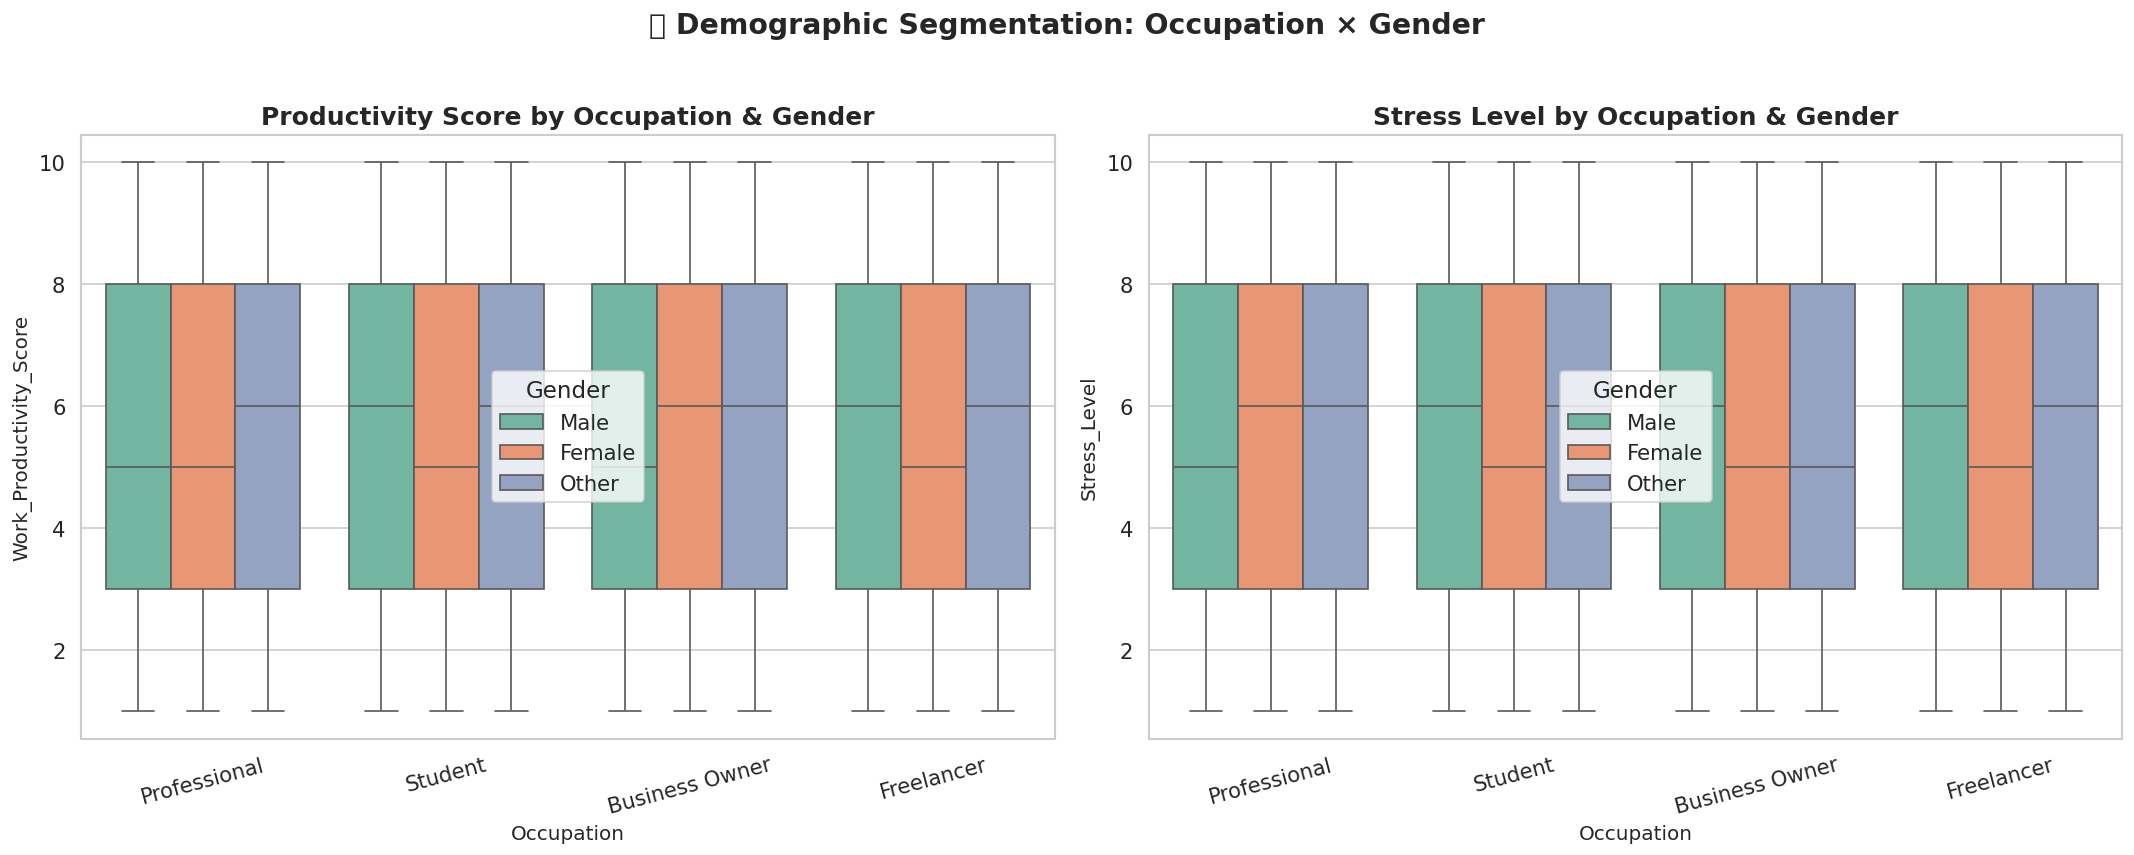

Kruskal-Wallis for Work_Productivity_Score across Occupations: H=1.83, p=0.6075 → ❌ Not significant
Kruskal-Wallis for Stress_Level across Occupations: H=4.10, p=0.2504 → ❌ Not significant


In [17]:
# Demographic Segmentation — Occupation × Gender

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Productivity by Occupation × Gender
sns.boxplot(data=df, x='Occupation', y='Work_Productivity_Score', hue='Gender',
            palette='Set2', ax=axes[0], fliersize=2)
axes[0].set_title('Productivity Score by Occupation & Gender', fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)

# Stress by Occupation × Gender
sns.boxplot(data=df, x='Occupation', y='Stress_Level', hue='Gender',
            palette='Set2', ax=axes[1], fliersize=2)
axes[1].set_title('Stress Level by Occupation & Gender', fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('👥 Demographic Segmentation: Occupation × Gender', fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Statistical test — Kruskal-Wallis across occupations
for target in ['Work_Productivity_Score', 'Stress_Level']:
    groups = [group[target].values for name, group in df.groupby('Occupation')]
    stat, p = stats.kruskal(*groups)
    sig = '✅ Significant' if p < 0.05 else '❌ Not significant'
    print(f'Kruskal-Wallis for {target} across Occupations: H={stat:.2f}, p={p:.4f} → {sig}')

/tmp/ipython-input-1023668518.py:36: UserWarning: Glyph 128241 (\N{MOBILE PHONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128241 (\N{MOBILE PHONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


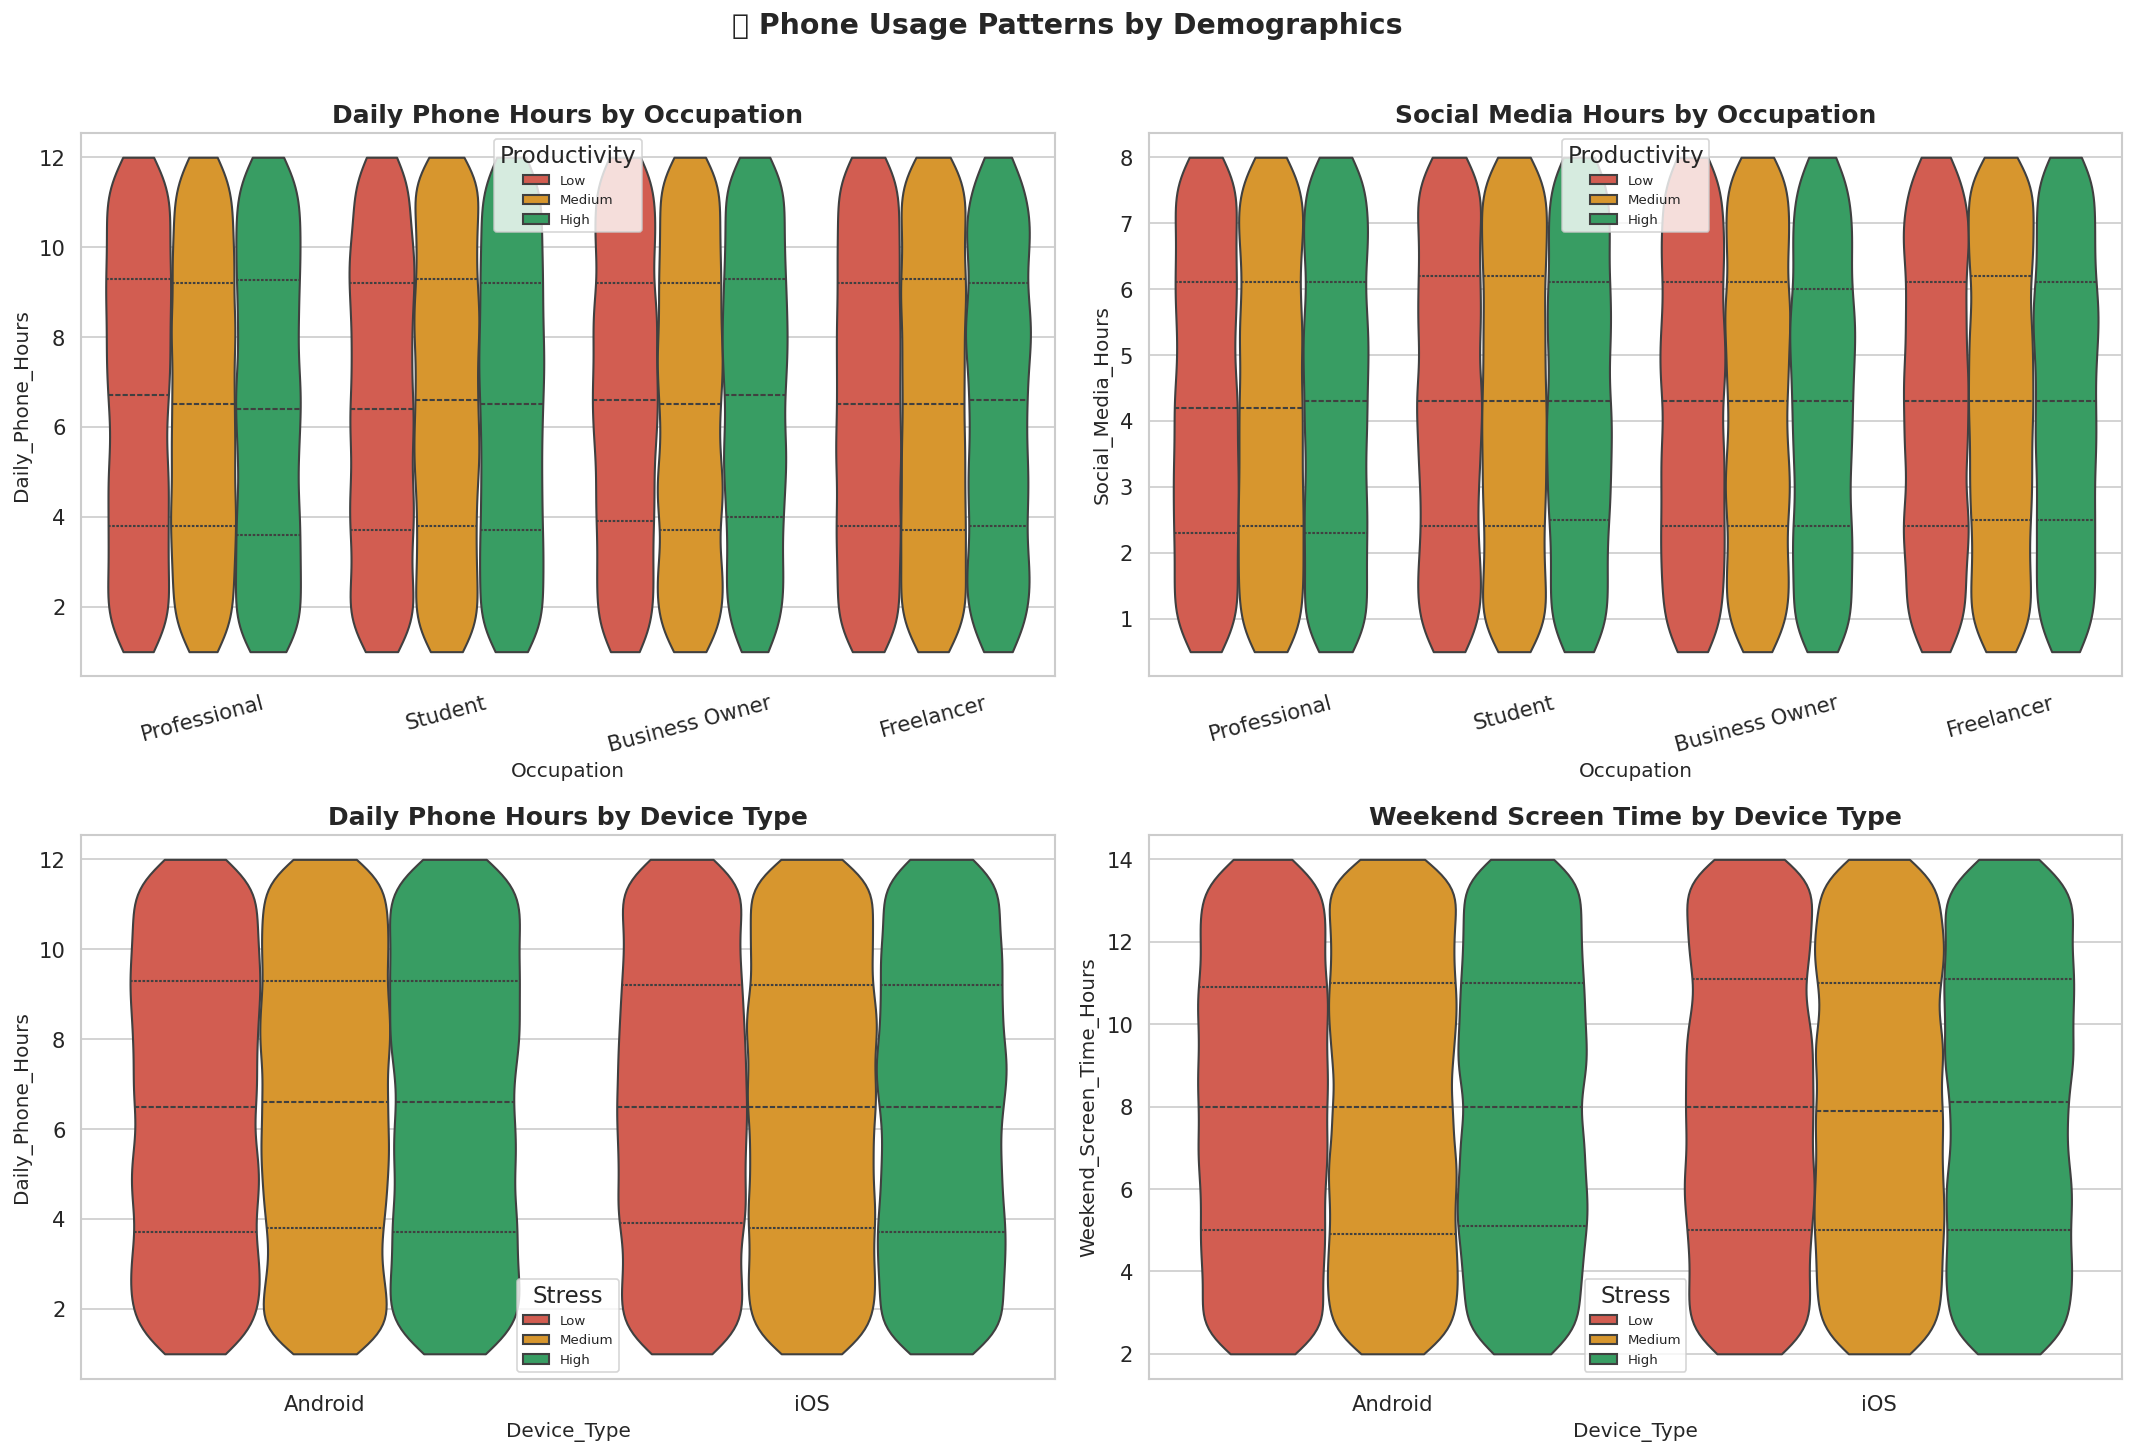

In [18]:
# Phone Usage Patterns — Violin Plots

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Daily Phone Hours by Occupation
sns.violinplot(data=df, x='Occupation', y='Daily_Phone_Hours', hue='Productivity_Class',
               hue_order=['Low', 'Medium', 'High'], palette=CLASS_PAL, ax=axes[0, 0],
               inner='quartile', cut=0, density_norm='width')
axes[0, 0].set_title('Daily Phone Hours by Occupation', fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=15)
axes[0, 0].legend(title='Productivity', fontsize=8)

# Social Media Hours by Occupation
sns.violinplot(data=df, x='Occupation', y='Social_Media_Hours', hue='Productivity_Class',
               hue_order=['Low', 'Medium', 'High'], palette=CLASS_PAL, ax=axes[0, 1],
               inner='quartile', cut=0, density_norm='width')
axes[0, 1].set_title('Social Media Hours by Occupation', fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=15)
axes[0, 1].legend(title='Productivity', fontsize=8)

# Daily Phone Hours by Device Type
sns.violinplot(data=df, x='Device_Type', y='Daily_Phone_Hours', hue='Stress_Class',
               hue_order=['Low', 'Medium', 'High'], palette=CLASS_PAL, ax=axes[1, 0],
               inner='quartile', cut=0, density_norm='width')
axes[1, 0].set_title('Daily Phone Hours by Device Type', fontweight='bold')
axes[1, 0].legend(title='Stress', fontsize=8)

# Weekend Screen Time by Device Type
sns.violinplot(data=df, x='Device_Type', y='Weekend_Screen_Time_Hours', hue='Stress_Class',
               hue_order=['Low', 'Medium', 'High'], palette=CLASS_PAL, ax=axes[1, 1],
               inner='quartile', cut=0, density_norm='width')
axes[1, 1].set_title('Weekend Screen Time by Device Type', fontweight='bold')
axes[1, 1].legend(title='Stress', fontsize=8)

plt.suptitle('📱 Phone Usage Patterns by Demographics', fontsize=17, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


/tmp/ipython-input-1721732569.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Caffeine_Intake_Cups', y='Stress_Level', ax=axes[0, 1],
/tmp/ipython-input-1721732569.py:20: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(values='Stress_Level', index='Age_Bin', columns='Caffeine_Intake_Cups',


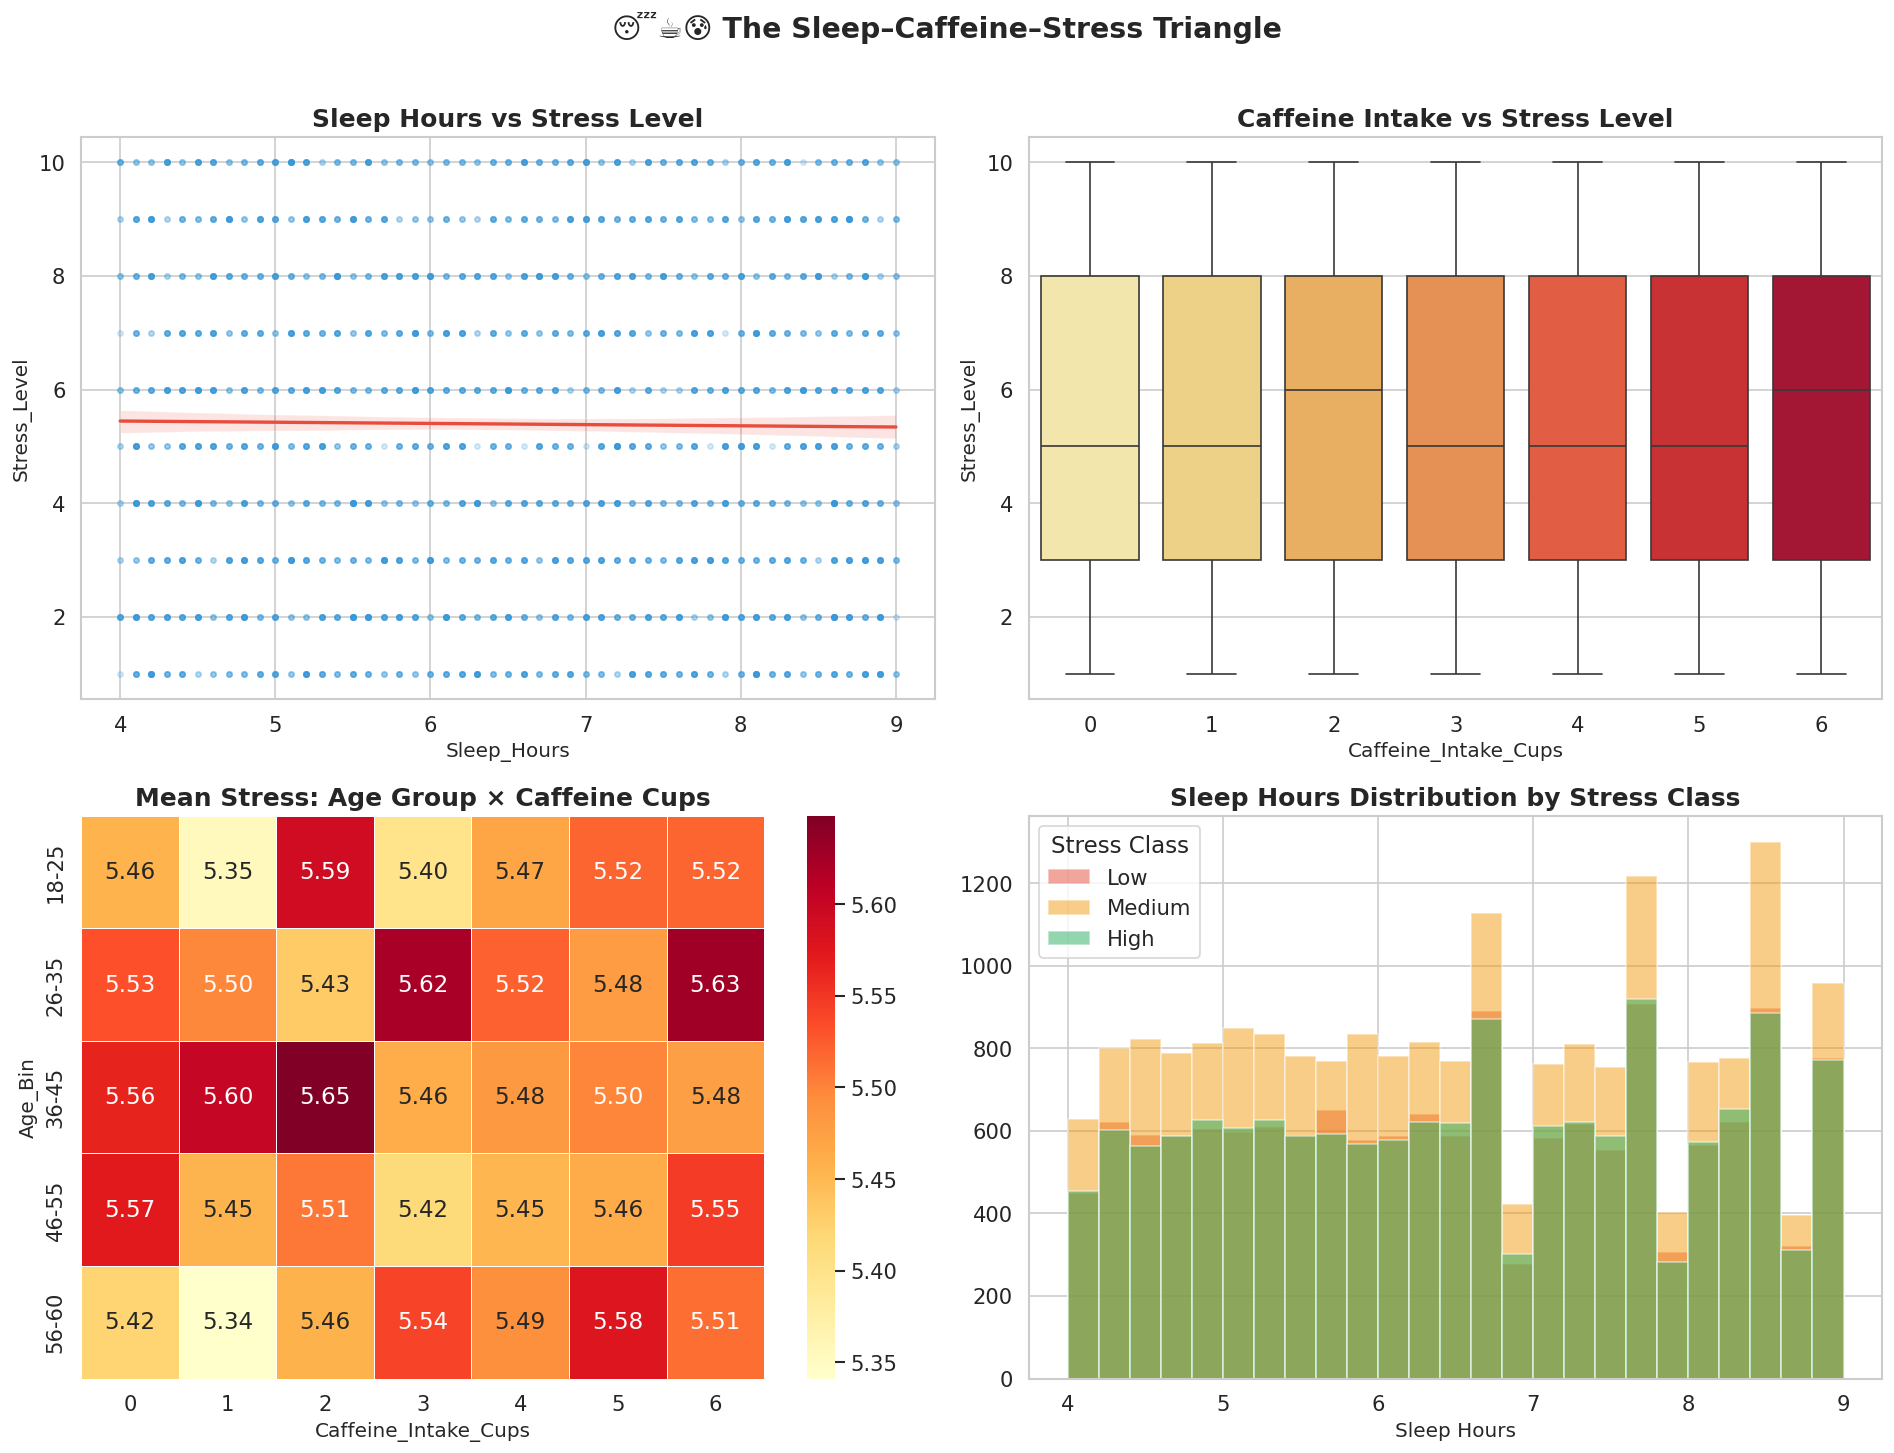

In [19]:
# Sleep, Caffeine & Stress Triangle

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1) Sleep vs Stress — scatter with regression
sample = df.sample(3000, random_state=42)
sns.regplot(data=sample, x='Sleep_Hours', y='Stress_Level', ax=axes[0, 0],
            scatter_kws={'alpha': 0.2, 's': 10, 'color': '#3498db'},
            line_kws={'color': '#e74c3c', 'linewidth': 2})
axes[0, 0].set_title('Sleep Hours vs Stress Level', fontweight='bold')

# 2) Caffeine vs Stress — boxplot
sns.boxplot(data=df, x='Caffeine_Intake_Cups', y='Stress_Level', ax=axes[0, 1],
            palette='YlOrRd', fliersize=2)
axes[0, 1].set_title('Caffeine Intake vs Stress Level', fontweight='bold')

# 3) Mean Stress by Age-bin × Caffeine — heatmap
df['Age_Bin'] = pd.cut(df['Age'], bins=[17, 25, 35, 45, 55, 60],
                       labels=['18-25', '26-35', '36-45', '46-55', '56-60'])
pivot = df.pivot_table(values='Stress_Level', index='Age_Bin', columns='Caffeine_Intake_Cups',
                       aggfunc='mean')
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[1, 0], linewidths=0.5)
axes[1, 0].set_title('Mean Stress: Age Group × Caffeine Cups', fontweight='bold')

# 4) Sleep distribution by Stress Class
for cls in ['Low', 'Medium', 'High']:
    sub = df[df['Stress_Class'] == cls]['Sleep_Hours']
    axes[1, 1].hist(sub, bins=25, alpha=0.5, label=cls, color=CLASS_PAL[cls], edgecolor='white')
axes[1, 1].set_title('Sleep Hours Distribution by Stress Class', fontweight='bold')
axes[1, 1].set_xlabel('Sleep Hours')
axes[1, 1].legend(title='Stress Class')

plt.suptitle('😴☕😰 The Sleep–Caffeine–Stress Triangle', fontsize=17, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()